# Gradient Boosting Regression

## 1. Imports

In [2]:
import pandas as pd # Load and manipulate tabular data
import numpy as np # Numerical calculations

import matplotlib.pyplot as plt # Create plots

from sklearn.model_selection import train_test_split # Split data into train/test sets
from sklearn.compose import ColumnTransformer # Apply preprocessing by column type
from sklearn.preprocessing import OneHotEncoder # Encode categorical variables
from sklearn.pipeline import Pipeline # Combine preprocessing and model steps

from sklearn.ensemble import GradientBoostingRegressor # Main Day 15 Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Regression Metrics








## 2. Load Data

In [3]:
df = pd.read_csv("../data/processed/member_analysis_ready.csv") # Load processed feature dataset 

df.head()

,member_id,age,gender,region,plan_type,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,prior_awv_rate,ed_visits,ip_admits,monthly_cost,awv_completed,engagement_group,age_group,high_cost_member,chronic_burden_group,sdoh_risk_group,prior_awv_group,total_acute_visits,acute_utilization_group,pcp_status,has_acute_utilization
0,M00001,69,Male,Suburban,Medicare Advantage,40.7,2,68.9,1,1,0.333333,2,0,3920.62,1,Q4_High,65-79,1,Moderate,Q1_Low,1,2,Low,Attributed,1
1,M00002,32,Female,Urban,DSNP,80.0,3,30.4,0,0,0.000000,2,0,2446.74,0,Q1_Low,18-34,0,Moderate,Q4_High,0,2,Low,Not Attributed,1
2,M00003,89,Female,Suburban,Medicare Advantage,49.6,3,86.3,1,3,1.000000,0,0,1419.49,1,Q4_High,80+,0,Moderate,Q2,3,0,NaN,Attributed,0
3,M00004,78,Male,Suburban,Medicare Advantage,45.7,4,63.1,1,1,0.333333,2,1,3703.93,1,Q4_High,65-79,1,High,Q1_Low,1,3,Moderate,Attributed,1
4,M00005,38,Male,Suburban,Medicare Advantage,32.4,0,55.6,0,0,0.000000,0,0,471.10,1,Q4_High,35-49,0,Low,Q1_Low,0,0,NaN,Not Attributed,0


## 3. Define target and features

In [4]:
target = "monthly_cost" # Regression target

drop_cols = [
    "member_id", # ID Columnl; not useful for prediction
    "monthly_cost", # Target column; must be removed from features
    "high_cost_member", # Derived from monthly_cost, so it leaks target information
    "awv_completed" # Excluded to keep this baseline cost model clean
]


X = df.drop(columns=drop_cols) # Create feature matrix
y = df[target]




## 4. Detect column types

In [6]:
categorical_cols = X.select_dtypes(
    include=["object", "string", "category", "bool"]
).columns.tolist() # Identify categorical columns

numeric_cols = X.select_dtypes(
    include=["int64","float64","int32","float32"]
).columns.tolist() # Identify numeric_cols

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)






Categorical columns: ['gender', 'region', 'plan_type', 'engagement_group', 'age_group', 'chronic_burden_group', 'sdoh_risk_group', 'acute_utilization_group', 'pcp_status']
Numeric columns: ['age', 'sdoh_risk_score', 'chronic_condition_count', 'engagement_score', 'pcp_attributed_24mo', 'prior_awv_count', 'prior_awv_rate', 'ed_visits', 'ip_admits', 'prior_awv_group', 'total_acute_visits', 'has_acute_utilization']


## 5. Train/test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,             # Feature matrix
    y,             # Target vector
    test_size=0.20, # Use 20% as test set
    random_state=42 # Make split reproducible 
)

## 6. Build preprocessor

In [8]:
preprocessor = ColumnTransformer(
    transformers = [
        (
            "cat",
            OneHotEncoder(handle_unknown = "ignore"),
            categorical_cols
        )
    ], 
    remainder = "passthrough" # Keep numeric columns unchanged
)

## 7. Build Gradient Boosting model

In [9]:
gb_model = Pipeline(
    steps = [
        ("preprocessor", preprocessor), # Encode categorical variables 
        (
            "model",
            GradientBoostingRegressor(
                n_estimators = 200, # Number of boosting stages
                learning_rate=0.05, # Smaller learning rate makes learning more gradual 
                max_depth = 3, # Shallow trees reduce overfitting 
                min_samples_leaf = 10, # Prevent tiny leaves
                random_state = 42 # Reproducible model
            )
        )
    ]
)

## 8. Fit Model

In [10]:
gb_model.fit(X_train, y_train) # Train Gradient Boosting model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

## 9. Evaluate model

In [11]:
y_train_pred = gb_model.predict(X_train) # Predict training data
y_test_pred = gb_model.predict(X_test) # Predict test data

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae =  mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

gb_results = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "MAE": [train_mae, test_mae],
    "RMSE": [train_rmse, test_rmse],
    "R2": [train_r2, test_r2]
})


gb_results



,Dataset,MAE,RMSE,R2
0,Train,296.643671,474.671936,0.857944
1,Test,371.718623,644.312041,0.770985


## 10. Actual vs predicted plot

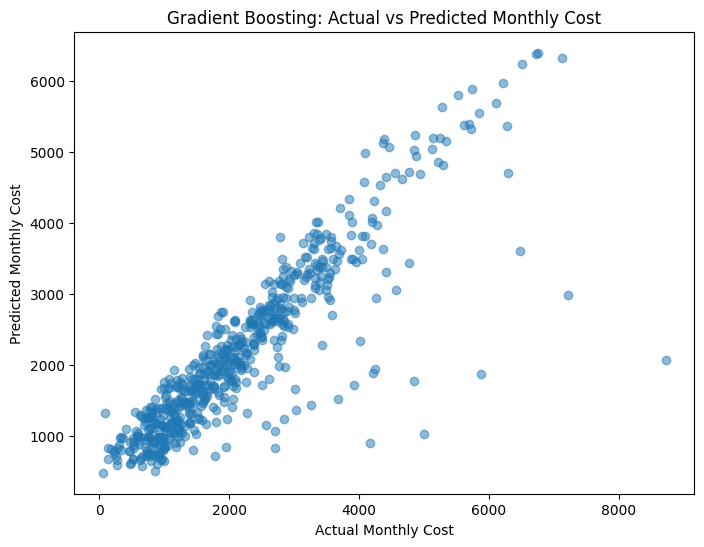

In [12]:
plt.figure(figsize = (8,6))

plt.scatter(y_test, y_test_pred, alpha = 0.5)

plt.xlabel("Actual Monthly Cost")
plt.ylabel("Predicted Monthly Cost")
plt.title("Gradient Boosting: Actual vs Predicted Monthly Cost")

plt.show()


## 11. Residual plot

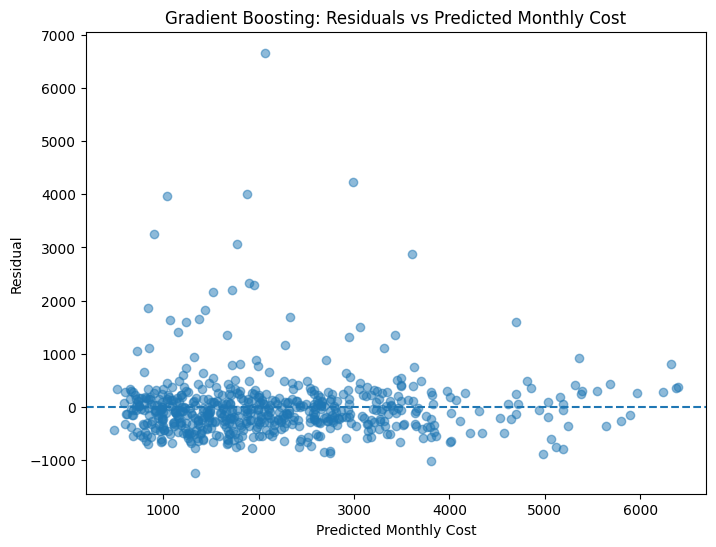

In [13]:
residuals = y_test - y_test_pred # Calculate prediction errors

plt.figure(figsize = (8,6))

plt.scatter(y_test_pred, residuals, alpha = 0.5)
plt.axhline(0, linestyle = "--")

plt.xlabel("Predicted Monthly Cost")
plt.ylabel("Residual")
plt.title("Gradient Boosting: Residuals vs Predicted Monthly Cost")

plt.show()

## 12. Feature importance

In [14]:
trained_preprocessor = gb_model.named_steps["preprocessor"]
trained_gb = gb_model.named_steps["model"] # Access fitted Gradient Boosting model

feature_names = trained_preprocessor.get_feature_names_out() # Get transformed feature names

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_gb.feature_importances_
}).sort_values(by = "importance", ascending = False)

importance_df.head(20)





,feature,importance
32,remainder__chronic_condition_count,0.292267
38,remainder__ip_admits,0.220047
17,cat__chronic_burden_group_High,0.205618
40,remainder__total_acute_visits,0.164108
5,cat__plan_type_DSNP,0.025047
30,remainder__age,0.021725
18,cat__chronic_burden_group_Low,0.015015
33,remainder__engagement_score,0.014478
31,remainder__sdoh_risk_score,0.006965
19,cat__chronic_burden_group_Moderate,0.006385


## 13. Plot top feature importances

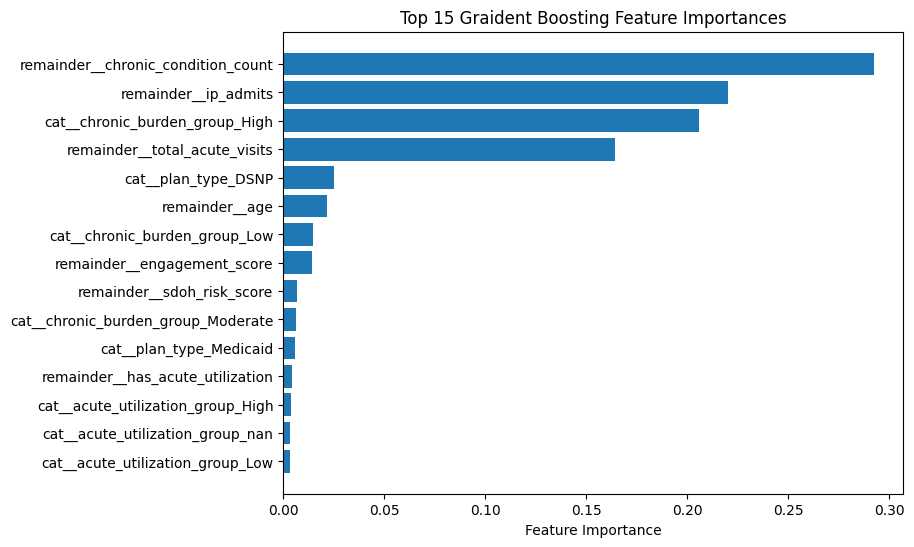

In [15]:
top_features = importance_df.head(15).sort_values(by="importance") # Sort for horizontal chart

plt.figure(figsize = (8,6))

plt.barh(top_features["feature"], top_features["importance"])

plt.xlabel("Feature Importance")
plt.title("Top 15 Graident Boosting Feature Importances")

plt.show()

# 14. Compare with previous models

In [16]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest",
        "Gradient Boosting", 
    ],
    "Test_MAE": [
        390.50,
        389.72,
        test_mae

    ],
    "Test RMSE": [
        665.28,
        665.61,
        test_rmse

    ],
    "Test R2": [
        0.76,
        0.76,
        test_r2


    ]

})
model_comparison



,Model,Test_MAE,Test RMSE,Test R2
0,Baseline Random Forest,390.500000,665.280000,0.760000
1,Tuned Random Forest,389.720000,665.610000,0.760000
2,Gradient Boosting,371.718623,644.312041,0.770985


## 15. Findings markdown

1. The Gradient Boosting Regressor was used as another nonlinear tree-based model for monthly cost prediction.

2. Unlike Random Forest, which averages many independent trees, Gradient Boosting builds trees sequentially so each new tree attempts to reduce prior prediction errors.

3. The model was evaluated using MAE, RMSE, and R² on both training and test data.

4. If Gradient Boosting improves test RMSE or test R² compared with Random Forest, that suggests boosting captured useful nonlinear structure in the synthetic dataset.

5. If Gradient Boosting performs worse, it may need tuning or may be less suitable for this specific synthetic data structure.

6. Feature importance values show predictive usefulness in this fitted model, not causal effects.

7. Because this project uses synthetic data, the findings reflect data-generation assumptions rather than real-world healthcare evidence.